In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
from cellseg_benchmark._constants import method_colors, cell_type_colors, methods_3D

In [2]:
sns.set_theme(rc={'figure.figsize':(12,8)}, style="whitegrid")

In [13]:
base_path = Path("/Users/jonasflor/Desktop/metrics_benchmark")
plot_path = base_path / "Plot_metrics" / "aging"

gen_stats = pd.read_csv(base_path / "data/aging/general_stats.csv", index_col=0)
comp_ana = pd.read_csv(base_path / "data/aging/cell_type_distribution_adata_integrated_cell_type_revised.csv", index_col=0).melt(id_vars=["method", "sample"], value_vars=["VLMCs", "BAMs", "SMCs", "Neurons-Dopa", "Neurons-Gaba", "Neurons-Glut", "Neurons-Glyc-Gaba", "Neurons-Granule-Immature", "Neurons-Other", 'Astrocytes', "Astroependymal", "ABCs", "OPCs", "Microglia", "ECs", "Pericytes", "Oligodendrocytes", "Undefined", "Immune-Other", "Ependymal", "Choroid-Plexus", "Tanycytes", "OECs", "Low-Read-Cells", "Undefined"], var_name="cell_type_revised", value_name="representation")
assign_tr = pd.read_csv(base_path / "data/aging/assigned_transcript_counts.csv", index_col=0)
marker_f1_stats = pd.read_csv(base_path / "data/aging/marker_f1_score_cell_type_revised.csv", index_col=0)
neg_purity_stats = pd.read_csv(base_path / "data/aging/negative_marker_purity_all.csv", index_col=0)
MECR_stats = pd.read_csv(base_path / "data/aging/MECR_score_all.csv", index_col=0)
clustering_stats = pd.read_csv(base_path / "data/aging/clustering_score_adata_integrated_cell_type_revised.csv", index_col=0)
ficture_f1 = pd.read_csv(base_path / "data/aging/ficture_f1.csv", index_col=0)

In [14]:
method_order = [x for x in method_colors.keys() if x in gen_stats['method'].unique()]

In [15]:
data = {"gen_stats": gen_stats, "comp_ana": comp_ana, "ass_tr": assign_tr, "marker_f1": marker_f1_stats, #"neg_purity": neg_purity_stats,
        "MECR": MECR_stats, "Clust_stats": clustering_stats,
        "fict": ficture_f1
        }

for c, d in data.items():
    print(f"{c}: {", ".join(d.columns)}")

gen_stats: method, sample, cell_type_revised, volume_final, area, sphericity, elongation, intensities_PolyT, intensities_DAPI, Ovrlpy_stats_mean_integrity, n_cells
comp_ana: method, sample, cell_type_revised, representation
ass_tr: method, sample, gene, assigned_count_qced, assigned_count_raw, total_count, pct_assigned_raw, pct_assigned_qced
marker_f1: method, sample, cell_type, marker_gene, f1_score, precision, recall, tp, fp, fn
MECR: method, sample, gene1, gene2, MECR
Clust_stats: method, sample, calinski_harabasz_score, silhouette_score
fict: method, sample, cell_type, tp, fp, fn, precision, recall, f1


In [16]:
comp_cluster_stats = comp_ana[comp_ana['cell_type_revised']=="Undefined"].merge(clustering_stats, on=['method', "sample"])
comp_cluster_stats

,method,sample,cell_type_revised,representation,calinski_harabasz_score,silhouette_score
0,Proseg_3D_Cellpose_1_nuclei_model,aging_s1_r1,Undefined,0.086592,41.882551,0.132877
1,Proseg_3D_Cellpose_1_nuclei_model,aging_s5_r1,Undefined,0.017006,54.975811,0.175062
2,Proseg_3D_Cellpose_1_nuclei_model,aging_s5_r2,Undefined,0.017541,47.317310,0.150272
3,Proseg_3D_Cellpose_1_nuclei_model,aging_s6_r0,Undefined,0.050179,47.433255,0.092531
4,Proseg_3D_Cellpose_1_nuclei_model,aging_s7_r1,Undefined,0.173359,45.192369,0.017340
...,...,...,...,...,...,...
618,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s11_r0,Undefined,0.306592,21.470101,-0.072984
619,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s11_r1,Undefined,0.323965,26.870367,-0.029836
620,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s11_r2,Undefined,0.255777,28.220808,0.019014
621,Baysor_2D_Cellpose_1_DAPI_PolyT_0.8,aging_s12_r0,Undefined,0.350559,18.117635,-0.081814


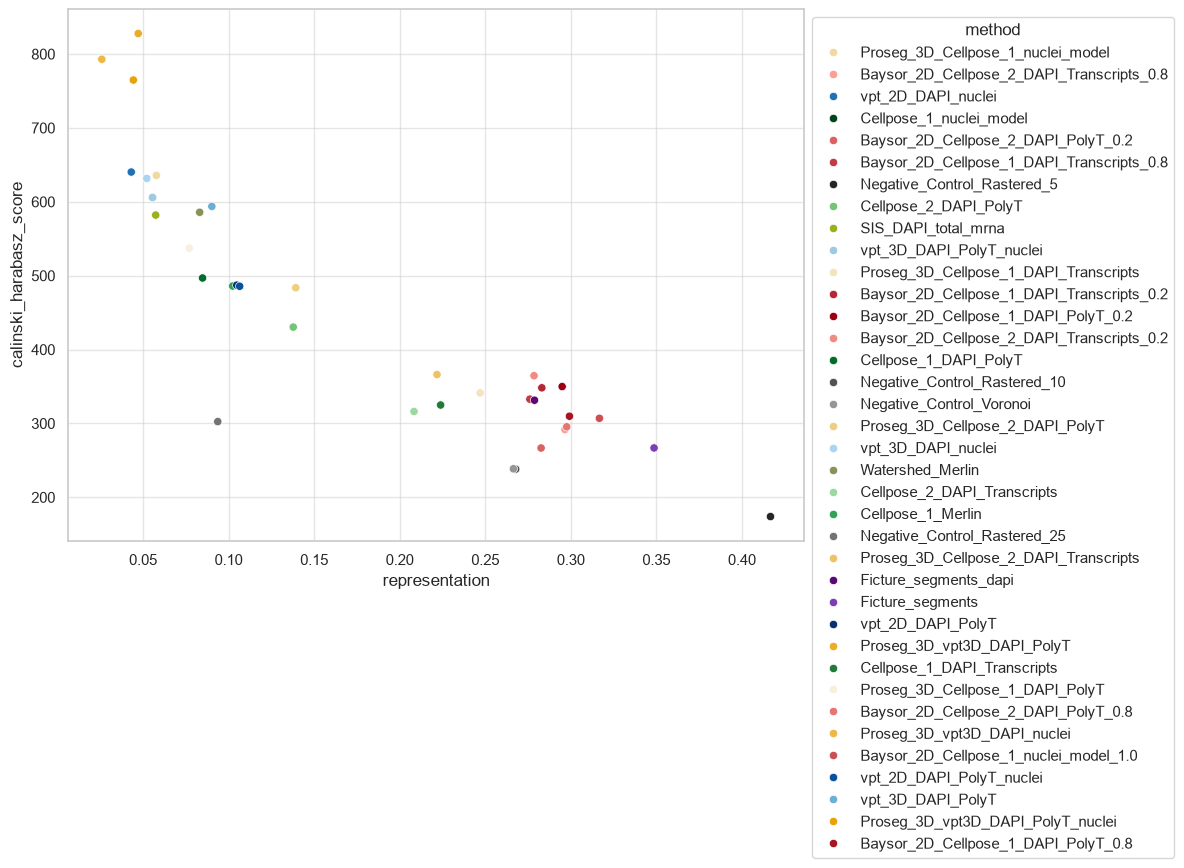

In [17]:
ax = sns.scatterplot(comp_cluster_stats[comp_cluster_stats['sample']=="all"], x="representation", y="calinski_harabasz_score", hue="method", palette=method_colors)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(plot_path / "undef_pct_sil_agg.svg")

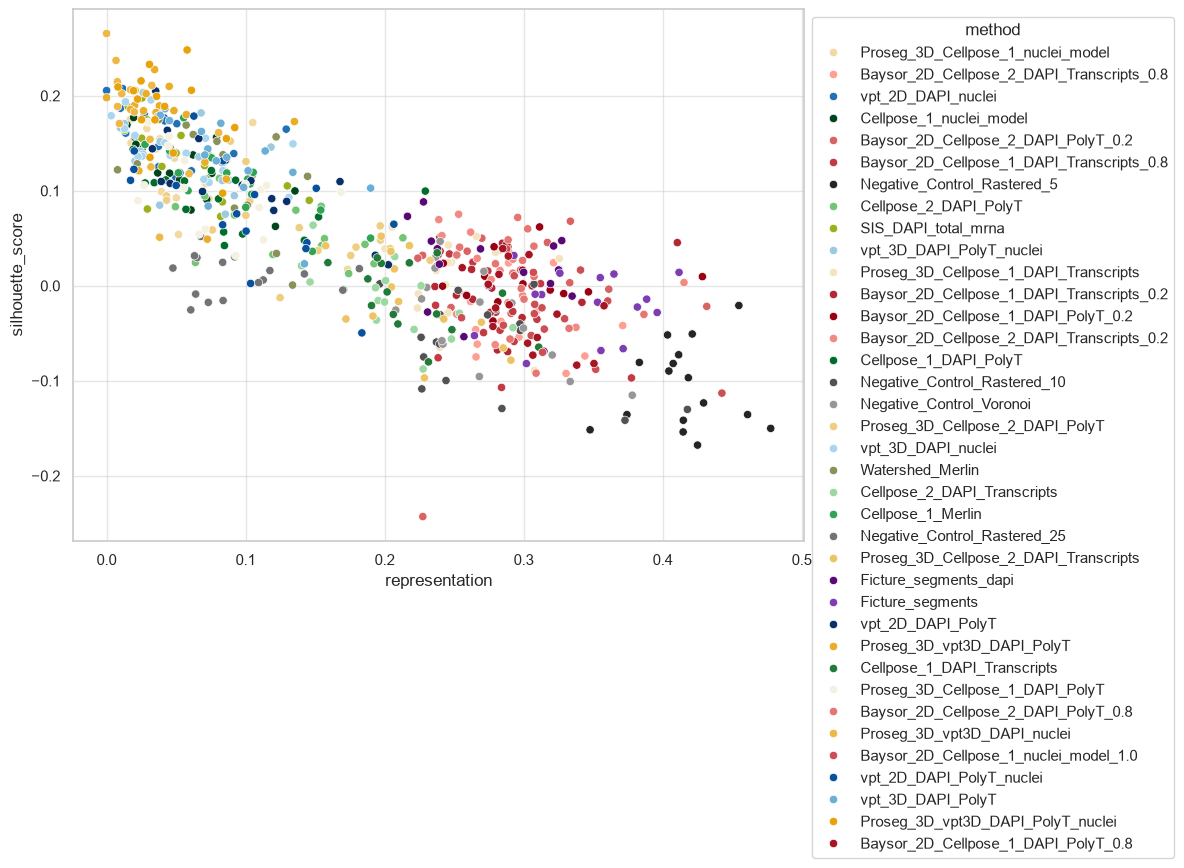

In [18]:
ax = sns.scatterplot(comp_cluster_stats[comp_cluster_stats['sample']!="all"], x="representation", y="silhouette_score", hue="method", palette=method_colors)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(plot_path / "undef_pct_sil_individual.svg")

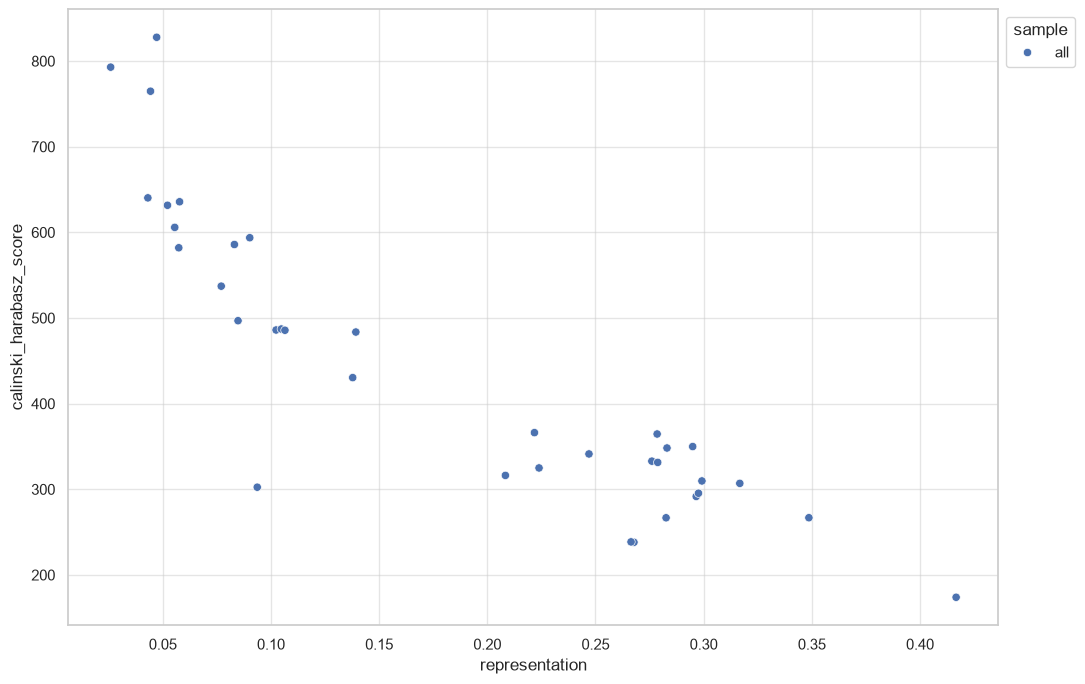

In [9]:
ax = sns.scatterplot(comp_cluster_stats[comp_cluster_stats['sample']=="all"], x="representation", y="calinski_harabasz_score", hue="sample")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

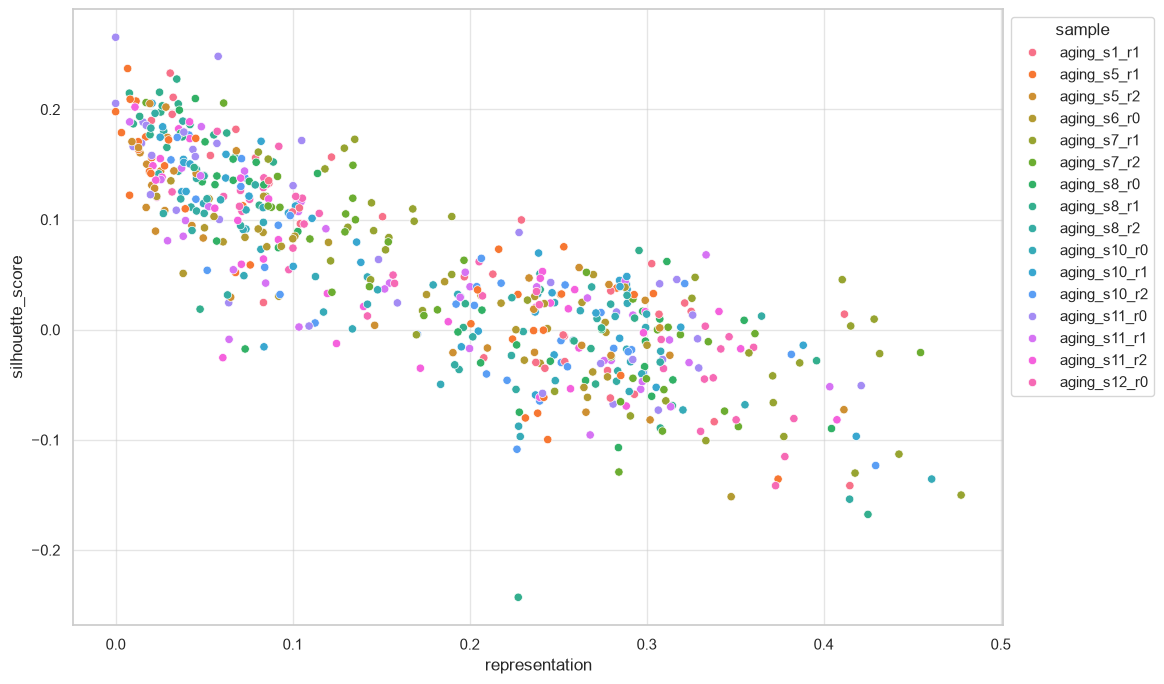

In [10]:
ax = sns.scatterplot(comp_cluster_stats[comp_cluster_stats['sample']!="all"], x="representation", y="silhouette_score", hue="sample")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))